In [3]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
# ============================================================
# 1) DISTANCE FUNCTIONS
# ============================================================

def pairwise_distances_l1(x, y=None):
    if y is None: y = x
    diff = x.unsqueeze(1) - y.unsqueeze(0)
    return diff.abs().sum(dim=-1)

def pairwise_distances_huber(x, y=None, delta=1.0):
    if y is None: y = x
    diff = x.unsqueeze(1) - y.unsqueeze(0)
    r = diff.norm(p=2, dim=-1)
    abs_r = r.abs()
    quadratic = 0.5 * abs_r**2
    linear = delta * (abs_r - 0.5 * delta)
    return torch.where(abs_r <= delta, quadratic, linear)

def pairwise_temporal_asymmetric(t_true, t_pred=None, late_weight=3.0, early_weight=1.0):
    if t_pred is None: t_pred = t_true
    s = (t_pred.unsqueeze(0) - t_true.unsqueeze(1)).squeeze(-1)
    weights = torch.where(s > 0,
                          torch.tensor(late_weight, device=s.device),
                          torch.tensor(early_weight, device=s.device))
    return weights * (s ** 2)

def pairwise_distances_l2(x, y=None):
    x_norm = (x**2).sum(1).view(-1, 1)
    if y is not None:
        y_t = y.t()
        y_norm = (y**2).sum(1).view(1, -1)
    else:
        y_t = x.t()
        y_norm = x_norm.view(1, -1)
    dist = x_norm + y_norm - 2.0 * torch.mm(x, y_t)
    return torch.clamp(dist, 0.0, float('inf'))


In [5]:
# ============================================================
# 2) SYNTHETIC TIME INDICES
# ============================================================

t_true = torch.arange(0, 7).float().view(-1,1)  # [0,1,2,3,4,5,6]
t_pred = torch.arange(1, 8).float().view(-1,1)  # shifted by +1



In [6]:
# ============================================================
# 3) COMPUTE ALL DISTANCE MATRICES
# ============================================================

D_L2   = pairwise_distances_l2(t_true, t_pred)
D_L1   = pairwise_distances_l1(t_true, t_pred)
D_Huber = pairwise_distances_huber(t_true, t_pred, delta=1.0)
D_ASYM = pairwise_temporal_asymmetric(t_true, t_pred, late_weight=3.0, early_weight=1.0)

print("========= L2 DISTANCE =========")
print(D_L2, "\n")

print("========= L1 DISTANCE =========")
print(D_L1, "\n")

print("========= HUBER DISTANCE (delta=1) =========")
print(D_Huber, "\n")

print("========= ASYMMETRIC DISTANCE (late=3, early=1) =========")
print(D_ASYM, "\n")


========= L2 DISTANCE =========
tensor([[ 1.,  4.,  9., 16., 25., 36., 49.],
        [ 0.,  1.,  4.,  9., 16., 25., 36.],
        [ 1.,  0.,  1.,  4.,  9., 16., 25.],
        [ 4.,  1.,  0.,  1.,  4.,  9., 16.],
        [ 9.,  4.,  1.,  0.,  1.,  4.,  9.],
        [16.,  9.,  4.,  1.,  0.,  1.,  4.],
        [25., 16.,  9.,  4.,  1.,  0.,  1.]]) 

========= L1 DISTANCE =========
tensor([[1., 2., 3., 4., 5., 6., 7.],
        [0., 1., 2., 3., 4., 5., 6.],
        [1., 0., 1., 2., 3., 4., 5.],
        [2., 1., 0., 1., 2., 3., 4.],
        [3., 2., 1., 0., 1., 2., 3.],
        [4., 3., 2., 1., 0., 1., 2.],
        [5., 4., 3., 2., 1., 0., 1.]]) 

========= HUBER DISTANCE (delta=1) =========
tensor([[0.5000, 1.5000, 2.5000, 3.5000, 4.5000, 5.5000, 6.5000],
        [0.0000, 0.5000, 1.5000, 2.5000, 3.5000, 4.5000, 5.5000],
        [0.5000, 0.0000, 0.5000, 1.5000, 2.5000, 3.5000, 4.5000],
        [1.5000, 0.5000, 0.0000, 0.5000, 1.5000, 2.5000, 3.5000],
        [2.5000, 1.5000, 0.5000, 0.0000,

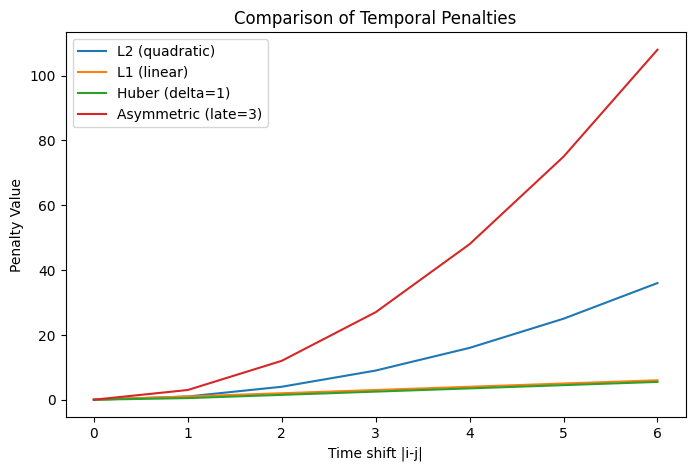

In [7]:
# ============================================================
# 4) PLOT PENALTY SHAPES
# ============================================================

shifts = torch.arange(0,7).float()

plt.figure(figsize=(8,5))
plt.plot(shifts, shifts**2, label="L2 (quadratic)")
plt.plot(shifts, shifts, label="L1 (linear)")
huber = torch.where(shifts<=1.0,0.5*shifts**2,1.0*(shifts-0.5))
plt.plot(shifts, huber, label="Huber (delta=1)")
plt.plot(shifts, 3*(shifts**2), label="Asymmetric (late=3)")
plt.xlabel("Time shift |i-j|")
plt.ylabel("Penalty Value")
plt.title("Comparison of Temporal Penalties")
plt.legend()
plt.show()


| Reason                   | Then use       |
| ------------------------------------- | -------------- |
| Time matters a lot                 | **L2**         |
| Shape matters more than time            | **L1**         |
| Time matters locally but don’t panic          | **Huber**      |
| Being late is dangerous / expensive | **Asymmetric** |
